## Task 1: Introduction to Machine Vision

### From Lab Session 1

#### Part I
<b>
Present the plots for the Red, Green, Blue(RGB) image histogram channels of your own picture and analyse the results. For instance, what do we learn from the visualised red, green and blue components of the image histogram? The picture with which you are working needs to be shown in your report.
</b>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image

In [2]:
peacock = cv2.imread("./lab1/Images_Part_I/Peacock.jpg", cv2.IMREAD_COLOR_RGB)

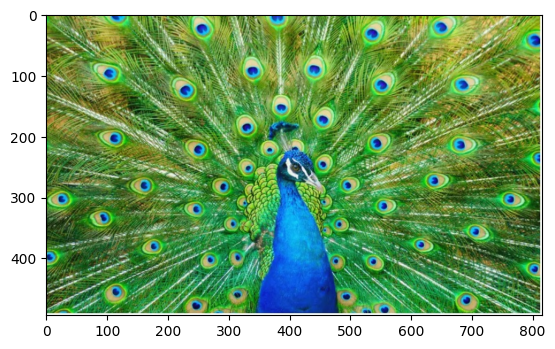

In [3]:
plt.imshow(peacock)

Text(0.5, 1.0, 'input image')

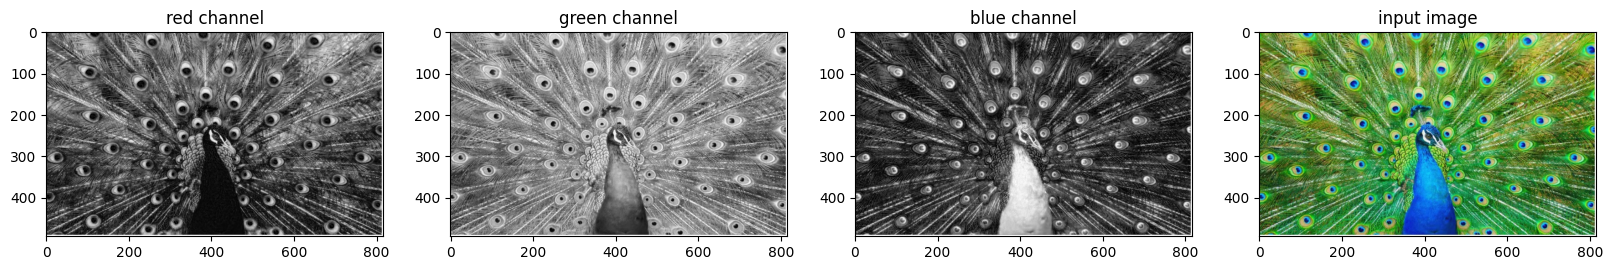

In [4]:
r, g, b = cv2.split(peacock)

plt.figure(figsize=[20,5])

plt.subplot(141)
plt.imshow(r, cmap='gray')
plt.title("red channel")

plt.subplot(142)
plt.imshow(g, cmap='gray')
plt.title("green channel")

plt.subplot(143)
plt.imshow(b, cmap='gray')
plt.title("blue channel")

imgMerged = cv2.merge((r,g,b))
plt.subplot(144)
plt.imshow(peacock)
plt.title("input image")

Text(0.5, 1.0, 'Histogram Blue Channel')

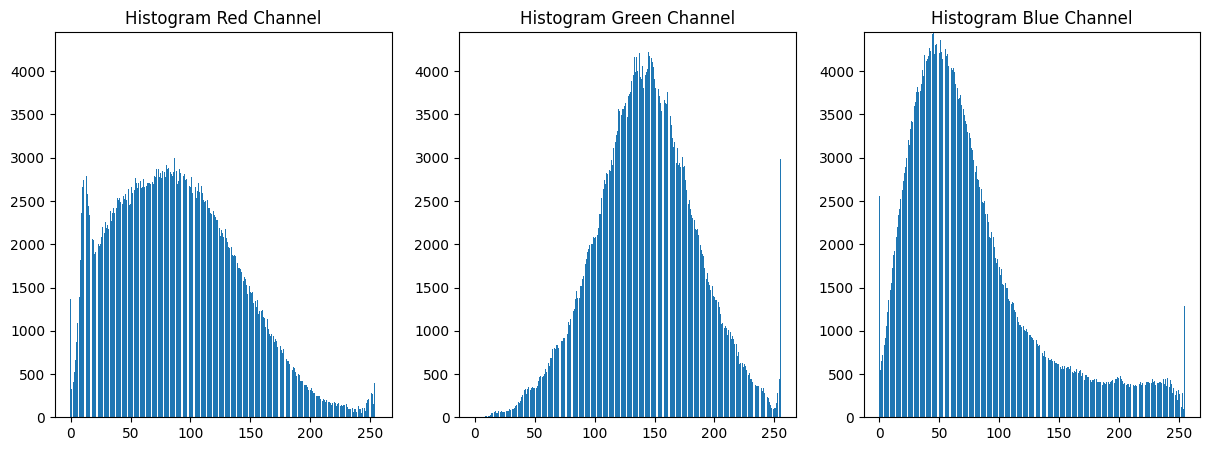

In [5]:
plt.figure(figsize=[20,5])

plt.subplot(141)
hist_r = cv2.calcHist([r],[0],None, [256], [0, 256])
plt.bar([i for i in range(256)],hist_r[:,0])
plt.ylim([0, 4450])
plt.title("Histogram Red Channel")

plt.subplot(142)
hist_g = cv2.calcHist([g],[0],None, [256], [0, 256])
plt.bar([i for i in range(256)],hist_g[:,0])
plt.ylim([0, 4450])
plt.title("Histogram Green Channel")

plt.subplot(143)
hist_b = cv2.calcHist([b],[0],None, [256], [0, 256])
plt.bar([i for i in range(256)],hist_b[:,0])
plt.ylim([0, 4450])
plt.title("Histogram Blue Channel")

#### From Lab Session 1 – Part II

Present results with different edge detection algorithms, e.g. Sobel, Prewitt and
Canny operators and comment on their accuracy with different threshold parameter
values. Include the images with the extracted edges in your report. Make conclusions
about the results, especially about static objects segmentation using edge detection in your report.

In [7]:
cookies_rgb = cv2.imread("./lab1/Images_Part_I/Cookies.jpg", cv2.IMREAD_COLOR_RGB)
cookies = cv2.cvtColor(cookies_rgb, cv2.COLOR_RGB2GRAY)

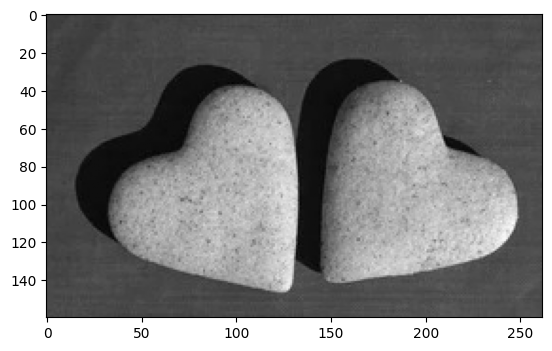

In [9]:
plt.imshow(cookies, cmap='gray')

#### Sobel Filter

In [11]:
sx = cv2.Sobel(cookies, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(cookies, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sx, sy)

Text(0.5, 1.0, 'Sobel Magnitude with threshold 350')

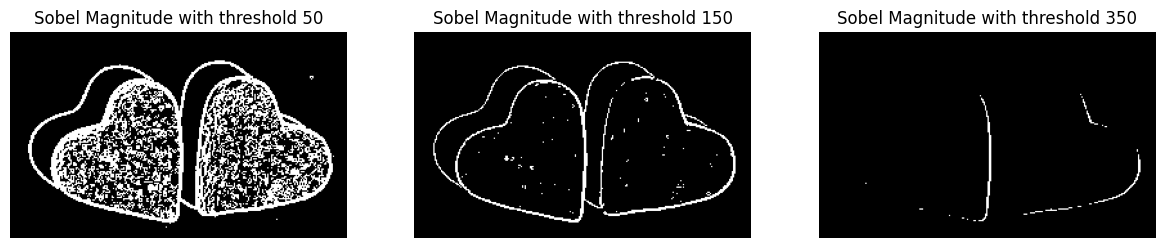

In [23]:
plt.figure(figsize=[20,5])

plt.subplot(141)
_, binary_50 = cv2.threshold(sobel, 50, 255, cv2.THRESH_BINARY)
plt.imshow(binary_50, cmap='gray')
plt.axis('off')
plt.title("Sobel Magnitude with threshold 50")

plt.subplot(142)
_, binary_150 = cv2.threshold(sobel, 150, 255, cv2.THRESH_BINARY)
plt.imshow(binary_150, cmap='gray')
plt.axis('off')
plt.title("Sobel Magnitude with threshold 150")

plt.subplot(143)
_, binary_350 = cv2.threshold(sobel, 350, 255, cv2.THRESH_BINARY)
plt.imshow(binary_350, cmap='gray')
plt.axis('off')
plt.title("Sobel Magnitude with threshold 350")

#### Prewitt Operator

In [32]:
kernel_x = np.array([[1,0,-1],
                     [1,0,-1],
                     [1,0,-1]])
kernel_y = np.array([[1, 1, 1],
                     [0, 0, 0],
                     [-1, -1, -1]])

px = cv2.filter2D(cookies, -1, kernel= kernel_x)
py = cv2.filter2D(cookies, -1, kernel=kernel_y)

prewitt = cv2.magnitude(np.float32(px), np.float32(py))

Text(0.5, 1.0, 'Prewitt Magnitude with threshold 150')

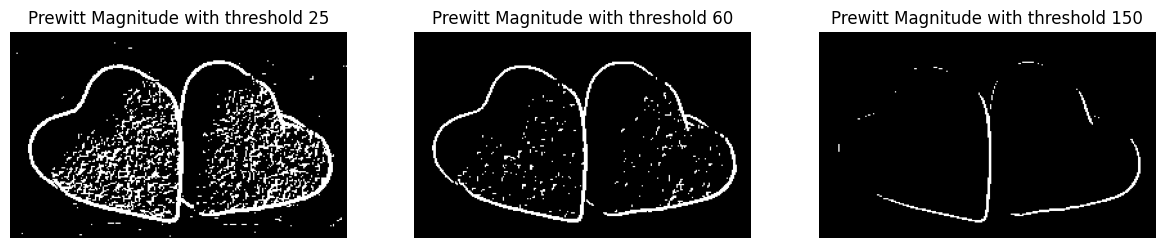

In [41]:
plt.figure(figsize=[20,5])

plt.subplot(141)
_, binary_25 = cv2.threshold(prewitt, 25, 255, cv2.THRESH_BINARY)
plt.imshow(binary_25, cmap='gray')
plt.axis('off')
plt.title("Prewitt Magnitude with threshold 25")

plt.subplot(142)
_, binary_60 = cv2.threshold(prewitt, 60, 255, cv2.THRESH_BINARY)
plt.imshow(binary_60, cmap='gray')
plt.axis('off')
plt.title("Prewitt Magnitude with threshold 60")

plt.subplot(143)
_, binary_150 = cv2.threshold(prewitt, 150, 255, cv2.THRESH_BINARY)
plt.imshow(binary_150, cmap='gray')
plt.axis('off')
plt.title("Prewitt Magnitude with threshold 150")

#### Canny Edge Detector

Text(0.5, 1.0, 'Canny with threshold 155 - 310')

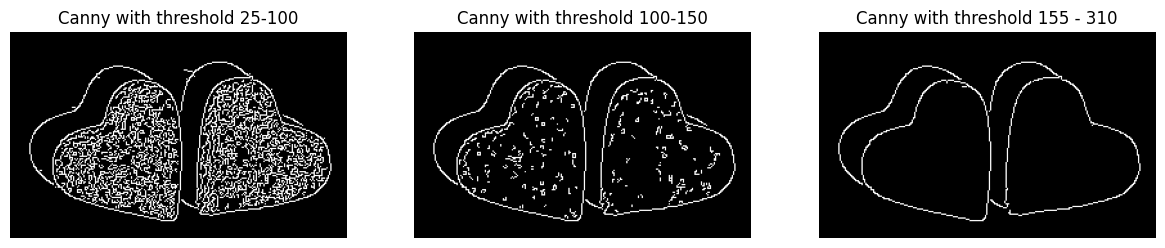

In [86]:
plt.figure(figsize=[20,5])

plt.subplot(141)
binary_25 = cv2.Canny(cookies, 25, 100)
plt.imshow(binary_25, cmap='gray')
plt.axis('off')
plt.title("Canny with threshold 25-100")

plt.subplot(142)
binary_100 = cv2.Canny(cookies, 100, 150)
plt.imshow(binary_100, cmap='gray')
plt.axis('off')
plt.title("Canny with threshold 100-150")

plt.subplot(143)
binary_155 = cv2.Canny(cookies, 155, 310)
plt.imshow(binary_155, cmap='gray')
plt.axis('off')
plt.title("Canny with threshold 155 - 310")